In [86]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import re

In [81]:
flavone = 'C1=CC=C(C=C1)C2=CC(=O)C3=CC=CC=C3O2'

mol = Chem.MolFromSmiles(flavone)
new_flavone = Chem.MolToSmiles(mol)
print(new_flavone)

O=c1cc(-c2ccccc2)oc2ccccc12


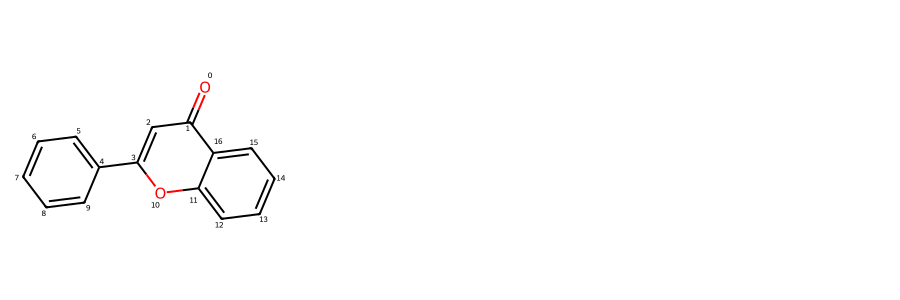

In [88]:
mol = Chem.MolFromSmiles(new_flavone)
IPythonConsole.drawOptions.addAtomIndices = True
Draw.MolsToGridImage([mol], subImgSize=(300,300))

In [97]:
base_rings = ['c1ccccc1', #benzene
               'n1ccccc1', #pyridine
               'o1cccc1',  #furan
               's1cccc1',  #thiophene
               '[nH]1cccc1', #pyrrole
               'n1c[nH]cc1', #imidazole
               'c1ccc2ccccc2c1', #naphthalene
               'c1ccc2cc3ccccc3cc2c1', #anthracene
              'O=c1cc(-c2ccccc2)oc2ccccc12'] #flavone

free_carbon_search_patterns = ['c1c', r'1c\[n', 'cc', r'c\[nH\]']
free_carbon_insert_points = [2, 2, 1, 1]

clean_ring_locations = [
  [1], #benzene
  [2, 3, 4], #pyridine
  [2, 3], #furan
  [2, 3], #thiophene
  [5, 6], #pyrrole
  [2, 7, 9], #imidazole
  [1, 3], #naphthalene
  [1, 3, 6],  #anthracene
  [4, 10, 11, 12, 13, 21, 22, 23]
]

e_withdraw = ['I', 'Br', 'Cl', 'F', 'C(Cl)(Cl)(Cl)', 'C(F)(F)(F)', 'C(=O)[O-]', 'C(=O)', 'C#N', '[N+](=O)[O-]', '[NH3+]']

e_donate = electron_donating_groups = [
    "[O-]",          # Phenoxide (strongest resonance donor)
    "N(C)C",         # Dimethylamino (-NMe2)
    "NC",            # Methylamino (-NHMe)
    "N",             # Amino (-NH2)
    "O",             # Hydroxy (-OH)
    "OC",            # Methoxy (-OMe)
    "NC(=O)C",       # Acetamido (-NHCOCH3)
    "SC",            # Methylthio (-SMe)
    "OC(=O)C",       # Acetoxy (-OCOCH3)
    "C(C)(C)C",      # tert-Butyl (-C(CH3)3)
    "C(C)C",         # Isopropyl (-CHMe2)
    "CC",            # Ethyl (-Et)
    "C",             # Methyl (-Me)
    "c1ccccc1",      # Phenyl (-Ph)
    "C=C",           # Vinyl (-CH=CH2)
    "[Si](C)(C)C"    # Trimethylsilyl (-SiMe3)
]

linkers = [
    "C",             # Methylene (-CH2-)
    "CC",            # Ethylene (-CH2CH2-)
    "CCC",           # Propylene (-CH2CH2CH2-)
    "C=C",           # Vinylene (-CH=CH-)
    "C#C",           # Acetylene (-C≡C-)
    "CC=C",          # Allylene (-CH2CH=CH-)
    "C=CC",          # Propenylene (-CH=CHCH2-)
    "O",             # Oxygen (-O-)
    "S",             # Sulfur (-S-)
    "N",             # Nitrogen (-NH-)
    "C(=O)",          # Carbonyl (-C(=O)-)
    "C(=O)O",        # Ester (-C(=O)O-)
    "C(=O)N",        # Amide (-C(=O)N-)
    "C(=O)C"       # Ketone (-C(=O)C-)
]

withdraw_with_linkers = [f'{linker}({e})' for linker in linkers for e in e_withdraw] 
donate_with_linkers = [f'{linker}({e})' for linker in linkers for e in e_donate]

target = 'hey'

In [99]:
def sub_cycle(best_smiles = '', best_score = 0, substituents = e_withdraw, target = target):
  '''

  '''
  for ring, locs in zip(base_rings, clean_ring_locations):
    for loc in locs:

      for e in substituents:

        new_smiles = f'{ring[:loc+1]}({e}){ring[loc+1:]}'
        new_mol = Chem.MolFromSmiles(new_smiles)
        if new_mol != None:
          print(new_smiles)
          try:
              score, aux = 1, 2 #target.dock(new_smiles, 32)
          except:
              print(f"Error docking {new_smiles}")
              score = 0.0
          #print(f"{new_smiles}: {score}")
          if score < best_score:
            best_score = score
            best_smiles = new_smiles       
            print(f"=========== New best score: {best_score} for {new_smiles} ======")
        else:
          print(new_smiles, 'bad')

  print(f"Best score: {best_score} for {best_smiles}")

  return best_smiles, best_score

def grow_cycle(best_smiles = '', best_score = 0, substituents = e_withdraw, target = target):
    '''
    add substituents to free carbons in the molecule. 
    '''
    match_indices = []
    for pattern, insert_point in zip(free_carbon_search_patterns, free_carbon_insert_points):
        for match in re.finditer(f'(?={pattern})', best_smiles):
            match_indices.append((pattern, best_smiles, match.start()))
            print(f'found match for {pattern} at {match.start() + insert_point}, {match.start()}')
            for e in substituents:
                new_smiles = f'{best_smiles[:match.start() + insert_point]}({e}){best_smiles[match.start() + insert_point:]}'
                mol = Chem.MolFromSmiles(new_smiles)
                if mol != None:
                    print(new_smiles)
                    try:
                        score, aux = 1, 2 #target.dock(new_smiles, 32)
                    except:
                        print(f"Error docking {new_smiles}")
                        score = 0.0
                    #print(f"{new_smiles}: {score}")
                    if score < best_score:
                        best_score = score
                        best_smiles = new_smiles       
                        print(f"=========== New best score: {best_score} for {new_smiles} ========")
                else:
                    print(new_smiles, 'bad')
    print(f"Best score: {best_score} for {best_smiles}")
    return best_smiles, best_score

In [100]:
bs, bs2 = grow_cycle(base_rings[-1], 0.0, withdraw_with_linkers)

found match for c1c at 4, 2
O=c1(C(I))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(Br))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(Cl))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(F))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(C(Cl)(Cl)(Cl)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(C(F)(F)(F)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(C(=O)[O-]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(C(=O)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C(C#N))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C([N+](=O)[O-]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(C([NH3+]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(I))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(Br))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(Cl))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(F))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(C(Cl)(Cl)(Cl)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(C(F)(F)(F)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(C(=O)[O-]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(C(=O)))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC(C#N))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC([N+](=O)[O-]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CC([NH3+]))cc(-c2ccccc2)oc2ccccc12 bad
O=c1(CCC(I))cc(-c2c

[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is greater than permitted
[10:55:52] Explicit valence for atom # 1 C, 6, is g

O=c1cc(-c2cc(C=CC([NH3+]))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(I))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(Br))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(Cl))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(F))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(C(Cl)(Cl)(Cl)))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(C(F)(F)(F)))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(C(=O)[O-]))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(C(=O)))ccc2)oc2ccccc12
O=c1cc(-c2cc(O(C#N))ccc2)oc2ccccc12
O=c1cc(-c2cc(O([N+](=O)[O-]))ccc2)oc2ccccc12
O=c1cc(-c2cc(O([NH3+]))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(I))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(Br))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(Cl))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(F))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(C(Cl)(Cl)(Cl)))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(C(F)(F)(F)))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(C(=O)[O-]))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(C(=O)))ccc2)oc2ccccc12
O=c1cc(-c2cc(S(C#N))ccc2)oc2ccccc12
O=c1cc(-c2cc(S([N+](=O)[O-]))ccc2)oc2ccccc12
O=c1cc(-c2cc(S([NH3+]))ccc2)oc2ccccc12
O=c1cc(-c2cc(N(I))ccc2)oc2ccccc12
O=c1cc(-c2cc(N(Br))ccc2)oc2ccccc12
O=c1cc(-c2cc(N(Cl))ccc2)oc2ccccc12


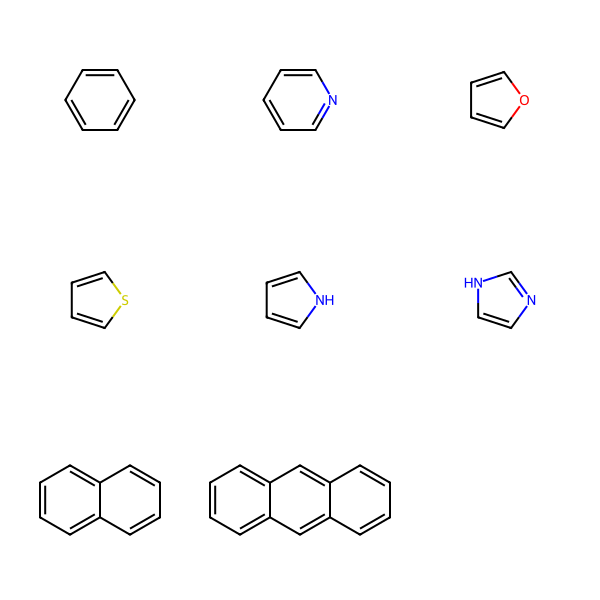

In [74]:
mols = [Chem.MolFromSmiles(s) for s in base_rings]
Draw.MolsToGridImage(mols)

In [28]:
bs, bs2 = sub_cycle()

c1(I)ccccc1
c1(Br)ccccc1
c1(Cl)ccccc1
c1(F)ccccc1
c1(C(Cl)(Cl)(Cl))ccccc1
c1(C(F)(F)(F))ccccc1
c1(C(=O)[O-])ccccc1
c1(C(=O))ccccc1
c1(C#N)ccccc1
c1([N+](=O)[O-])ccccc1
c1([NH3+])ccccc1
n1c(I)cccc1
n1c(Br)cccc1
n1c(Cl)cccc1
n1c(F)cccc1
n1c(C(Cl)(Cl)(Cl))cccc1
n1c(C(F)(F)(F))cccc1
n1c(C(=O)[O-])cccc1
n1c(C(=O))cccc1
n1c(C#N)cccc1
n1c([N+](=O)[O-])cccc1
n1c([NH3+])cccc1
n1cc(I)ccc1
n1cc(Br)ccc1
n1cc(Cl)ccc1
n1cc(F)ccc1
n1cc(C(Cl)(Cl)(Cl))ccc1
n1cc(C(F)(F)(F))ccc1
n1cc(C(=O)[O-])ccc1
n1cc(C(=O))ccc1
n1cc(C#N)ccc1
n1cc([N+](=O)[O-])ccc1
n1cc([NH3+])ccc1
n1ccc(I)cc1
n1ccc(Br)cc1
n1ccc(Cl)cc1
n1ccc(F)cc1
n1ccc(C(Cl)(Cl)(Cl))cc1
n1ccc(C(F)(F)(F))cc1
n1ccc(C(=O)[O-])cc1
n1ccc(C(=O))cc1
n1ccc(C#N)cc1
n1ccc([N+](=O)[O-])cc1
n1ccc([NH3+])cc1
o1c(I)ccc1
o1c(Br)ccc1
o1c(Cl)ccc1
o1c(F)ccc1
o1c(C(Cl)(Cl)(Cl))ccc1
o1c(C(F)(F)(F))ccc1
o1c(C(=O)[O-])ccc1
o1c(C(=O))ccc1
o1c(C#N)ccc1
o1c([N+](=O)[O-])ccc1
o1c([NH3+])ccc1
o1cc(I)cc1
o1cc(Br)cc1
o1cc(Cl)cc1
o1cc(F)cc1
o1cc(C(Cl)(Cl)(Cl))cc1
o1cc(C(F)(F)(F))c

In [49]:
for i in range(len(base_rings)):
    bs, bs2 = grow_cycle(base_rings[i])

found match
c1(I)ccccc1
c1(Br)ccccc1
c1(Cl)ccccc1
c1(F)ccccc1
c1(C(Cl)(Cl)(Cl))ccccc1
c1(C(F)(F)(F))ccccc1
c1(C(=O)[O-])ccccc1
c1(C(=O))ccccc1
c1(C#N)ccccc1
c1([N+](=O)[O-])ccccc1
c1([NH3+])ccccc1
found match
c1c(I)cccc1
c1c(Br)cccc1
c1c(Cl)cccc1
c1c(F)cccc1
c1c(C(Cl)(Cl)(Cl))cccc1
c1c(C(F)(F)(F))cccc1
c1c(C(=O)[O-])cccc1
c1c(C(=O))cccc1
c1c(C#N)cccc1
c1c([N+](=O)[O-])cccc1
c1c([NH3+])cccc1
found match
c1ccc(I)cc1
c1ccc(Br)cc1
c1ccc(Cl)cc1
c1ccc(F)cc1
c1ccc(C(Cl)(Cl)(Cl))cc1
c1ccc(C(F)(F)(F))cc1
c1ccc(C(=O)[O-])cc1
c1ccc(C(=O))cc1
c1ccc(C#N)cc1
c1ccc([N+](=O)[O-])cc1
c1ccc([NH3+])cc1
Best score: 0 for c1ccccc1
found match
n1ccc(I)cc1
n1ccc(Br)cc1
n1ccc(Cl)cc1
n1ccc(F)cc1
n1ccc(C(Cl)(Cl)(Cl))cc1
n1ccc(C(F)(F)(F))cc1
n1ccc(C(=O)[O-])cc1
n1ccc(C(=O))cc1
n1ccc(C#N)cc1
n1ccc([N+](=O)[O-])cc1
n1ccc([NH3+])cc1
found match
n1c(I)cccc1
n1c(Br)cccc1
n1c(Cl)cccc1
n1c(F)cccc1
n1c(C(Cl)(Cl)(Cl))cccc1
n1c(C(F)(F)(F))cccc1
n1c(C(=O)[O-])cccc1
n1c(C(=O))cccc1
n1c(C#N)cccc1
n1c([N+](=O)[O-])cccc1
n1c([

[16:37:00] SMILES Parse Error: syntax error while parsing: n1c[n(I)H]cc1
[16:37:00] SMILES Parse Error: check for mistakes around position 6:
[16:37:00] n1c[n(I)H]cc1
[16:37:00] ~~~~~^
[16:37:00] SMILES Parse Error: Failed parsing SMILES 'n1c[n(I)H]cc1' for input: 'n1c[n(I)H]cc1'
[16:37:00] SMILES Parse Error: syntax error while parsing: n1c[n(Br)H]cc1
[16:37:00] SMILES Parse Error: check for mistakes around position 6:
[16:37:00] n1c[n(Br)H]cc1
[16:37:00] ~~~~~^
[16:37:00] SMILES Parse Error: Failed parsing SMILES 'n1c[n(Br)H]cc1' for input: 'n1c[n(Br)H]cc1'
[16:37:00] SMILES Parse Error: syntax error while parsing: n1c[n(Cl)H]cc1
[16:37:00] SMILES Parse Error: check for mistakes around position 6:
[16:37:00] n1c[n(Cl)H]cc1
[16:37:00] ~~~~~^
[16:37:00] SMILES Parse Error: Failed parsing SMILES 'n1c[n(Cl)H]cc1' for input: 'n1c[n(Cl)H]cc1'
[16:37:00] SMILES Parse Error: syntax error while parsing: n1c[n(F)H]cc1
[16:37:00] SMILES Parse Error: check for mistakes around position 6:
[16:37: